# $\text{ARIMA}(p,d,q)$

ARIMA stands for Auto Regressive Integrated Moving Average. The intent of $\text{ARIMA}(p,d,q)$ is to construct a stationary, $\text{ARMA}(p,q)$ time series from a non-stationary time series by differencing $d$ times. Recall that an $\text{ARMA}(p,q)$ process is defined by,

$
\begin{align}
X_t = \varepsilon_t + \sum_{i=1}^p \varphi_i X_{t-i} + \sum_{i=1}^q \vartheta_i \varepsilon_{t-i}
\end{align}
\tag{1}
$

In terms of the lag operator $L X_t = X_{t-1}, L^2 X_t = X_{t-2}, L^3 X_t = X_{t-3}, \ldots$, The $\text{ARMA}(p,q)$ model can be written as,

$
\begin{align}
\left( 1 - \sum_{i=1}^p \varphi_i L^i \right) X_t = \left( 1  + \sum_{i=1}^q \vartheta_i L^i \right)\varepsilon_{t}
\end{align}
\tag{2}
$

The difference operator is given by $\Delta = (1 - L)$. If $X_t$ is stationary after $d$ differences it follows that $\left( 1 - L \right)^d X_t$ is stationary. This is the definition of integration order. Thus, $\text{ARIMA}(p,d,q)$ can be written as,

$
\begin{align}
\left( 1 - \sum_{i=1}^p \varphi_i L^i \right) \left( 1 - L \right)^d X_t = \left( 1  + \sum_{i=1}^q \vartheta_i L^i \right)\varepsilon_{t}
\end{align}
\tag{3}
$

The procedure followed to determine the order and coefficients of an $\text{ARIMA}(p,d,q)$ series is as follows.

1. Use ADF test to determine if series is stationary. To determine $d$ difference series until ADF test fails.
2. User PACF/ACF analysis to determine $p$ and $q$.
3. Perform regression on differenced series to determine coefficients.

## Includes

In [2]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import arima, stats, adf
from lib.plots import stack, comparison

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [3]:
nsample = 1000

def pacf_acf_plot(t, samples, nlags, σ, φ):
    title = f"AR(1) ACF-PACF σ={σ}, $\\varphi=${φ}"
    tacf, acf = stats.compute_acf(t, samples, nlags=nlags)
    tpacf, pacf = arima.compute_pacf(samples, nlags=nlags)
    comparison([acf, pacf], [tacf, tpacf], labels=["ACF", "PACF"], ylim=(-0.1, 1.0), title=title, figsize=(10, 6))

## $\text{ARIMA}(1,1,0)$ Example

In [4]:
nsample = 1000
σ = 1.0
nlags = 10

In [5]:
φ = [0.5]
d = 1
_, ar = arima.create_ar_source(φ=φ, npts=nsample)
t, arima_data = arima.create_arima_from_arma_source(arma=ar, d=d, npts=nsample)
tdiff_1, diff_1 = stats.compute_ndiff(t, arima_data, ndiff=1)

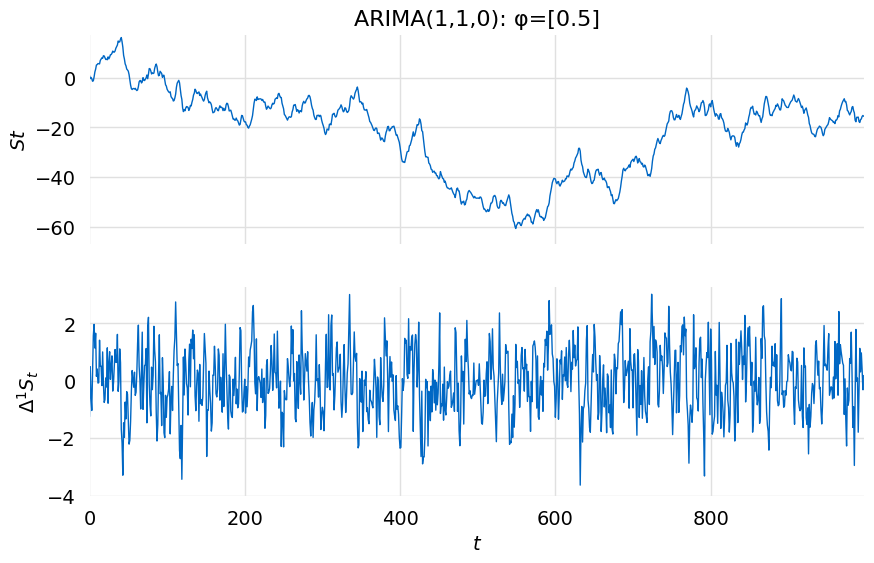

In [6]:
title=f"ARIMA(1,1,0): φ={φ}"
stack([arima_data, diff_1], title=title, xlabel=r"$t$", ylabels=[r"$St$", r"$\Delta^1 S_t$"])

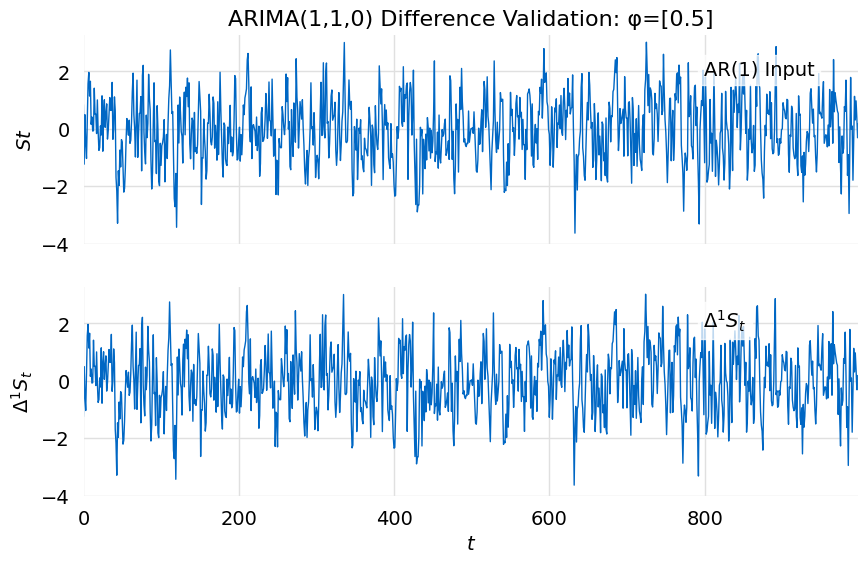

In [7]:
title = f"ARIMA(1,1,0) Difference Validation: φ={φ}"
stack([ar, diff_1], title=title, labels=[r"AR(1) Input", r"$\Delta^1 S_t$"], xlabel=r"$t$", ylabels=[r"$St$", r"$\Delta^1 S_t$"])

In [8]:
result, report = adf.compute_adf_test(arima_data)
result.summary()

╒════════════════╤═══════════╕
│ Test Statistic │  -1.00808 │
├────────────────┼───────────┤
│ pvalue         │   0.28487 │
├────────────────┼───────────┤
│ Lags           │   1       │
├────────────────┼───────────┤
│ Number Obs     │ 998       │
╘════════════════╧═══════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


In [9]:
report.dict

{'Status': False,
 'HypothesisType': <HypothesisType.LOWER_TAIL: 'LOWER_TAIL'>,
 'HypothesisTestType': <HypothesisTestType.STATIONARITY: 'STATIONARITY'>,
 'Description': 'Stationarity Test',
 'TestData': [{'Status': True,
   'Statistic': {'Value': -1.008084993042494, 'Label': '$t$'},
   'PValue': {'Value': 0.28486984700259843, 'Label': '$p-value$'},
   'Parameters': [],
   'Significance': {'Value': 0.01, 'Label': '1%'},
   'Lower Critical Value': {'Value': -2.5679839221127625, 'Label': '$t_L$'},
   'Upper Critical Value': None},
  {'Status': True,
   'Statistic': {'Value': -1.008084993042494, 'Label': '$t$'},
   'PValue': {'Value': 0.28486984700259843, 'Label': '$p-value$'},
   'Parameters': [],
   'Significance': {'Value': 0.05, 'Label': '5%'},
   'Lower Critical Value': {'Value': -1.9412724853659513, 'Label': '$t_L$'},
   'Upper Critical Value': None},
  {'Status': True,
   'Statistic': {'Value': -1.008084993042494, 'Label': '$t$'},
   'PValue': {'Value': 0.28486984700259843, 'Label'

In [10]:
result, report = adf.compute_adf_test(diff_1)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -18.6322      │
├────────────────┼───────────────┤
│ pvalue         │   3.69212e-29 │
├────────────────┼───────────────┤
│ Lags           │   0           │
├────────────────┼───────────────┤
│ Number Obs     │ 998           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [11]:
report.dict

{'Status': True,
 'HypothesisType': <HypothesisType.LOWER_TAIL: 'LOWER_TAIL'>,
 'HypothesisTestType': <HypothesisTestType.STATIONARITY: 'STATIONARITY'>,
 'Description': 'Stationarity Test',
 'TestData': [{'Status': False,
   'Statistic': {'Value': -18.632246012028634, 'Label': '$t$'},
   'PValue': {'Value': 3.692121595188048e-29, 'Label': '$p-value$'},
   'Parameters': [],
   'Significance': {'Value': 0.01, 'Label': '1%'},
   'Lower Critical Value': {'Value': -2.5679839221127625, 'Label': '$t_L$'},
   'Upper Critical Value': None},
  {'Status': False,
   'Statistic': {'Value': -18.632246012028634, 'Label': '$t$'},
   'PValue': {'Value': 3.692121595188048e-29, 'Label': '$p-value$'},
   'Parameters': [],
   'Significance': {'Value': 0.05, 'Label': '5%'},
   'Lower Critical Value': {'Value': -1.9412724853659513, 'Label': '$t_L$'},
   'Upper Critical Value': None},
  {'Status': False,
   'Statistic': {'Value': -18.632246012028634, 'Label': '$t$'},
   'PValue': {'Value': 3.692121595188048e-

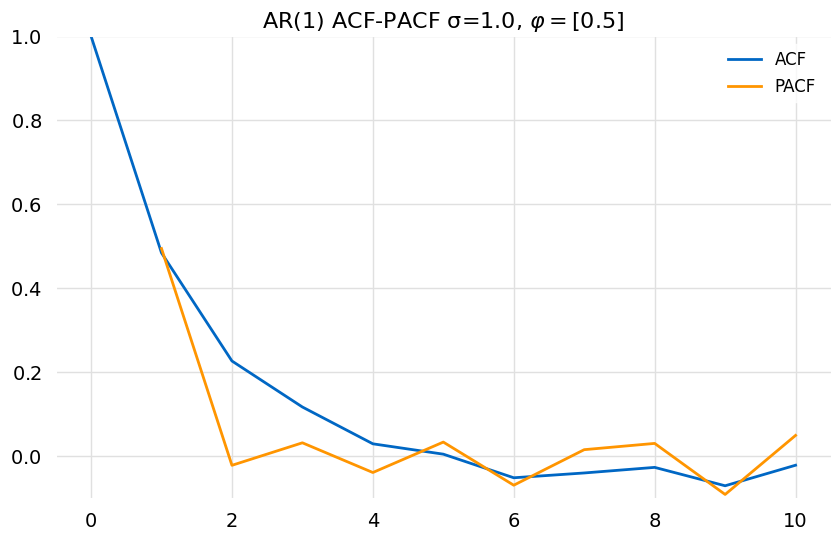

In [12]:
pacf_acf_plot(t, diff_1, nlags, σ, φ)

In [13]:
result, result_model = arima.compute_ar_estimate(diff_1, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1398.254
Date:                Sun, 23 Jul 2023   AIC                           2802.508
Time:                        11:17:03   BIC                           2817.228
Sample:                             0   HQIC                          2808.103
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0179      0.060     -0.298      0.766      -0.136       0.100
ar.L1          0.4840      0.028     17.127      0.000       0.429       0.539
sigma2         0.9619      0.045     21.230      0.000       0.873       1.051
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 1.71
Prob(Q):                              0.88   Prob(JB):                         0.42
Heteroskedasticity (H):               1.16   Skew:                             0.03
Prob(H) (two-sided):                  0.19   Kurtosis:                         2.81
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [14]:
result_model.dict

{'est_model': 'ARMA',
 'arma_est_type': 'AR',
 'order': 1,
 'const': {'Estimate': -0.017928947617880428,
  'Error': 0.06012173101576812,
  'Estimate Label': '$\\hat{\\mu^*}$',
  'Error Label': '$\\sigma_{\\hat{\\mu^*}}$'},
 'sigma2': {'Estimate': 0.9618896354958518,
  'Error': 0.04530703172667154,
  'Estimate Label': '$\\hat{\\sigma^2}$',
  'Error Label': '$\\sigma_{\\hat{\\sigma^2}}$'},
 'params': [{'Estimate': 0.48403413124234124,
   'Error': 0.028262235543137653,
   'Estimate Label': '$\\hat{\\phi_{0}}$',
   'Error Label': '$\\sigma_{$\\hat{\\phi_{0}}}$'}]}

## $\text{ARIMA}(1,2,0)$ Example

In [15]:
φ = [0.75]
d = 2
_, ar = arima.create_ar_source(φ=φ, npts=nsample)
t, arima_data = arima.create_arima_from_arma_source(arma=ar, d=d, npts=nsample)
tdiff_1, diff_1 = stats.compute_ndiff(t, arima_data, ndiff=1)
tdiff_2, diff_2 = stats.compute_ndiff(t, arima_data, ndiff=2)

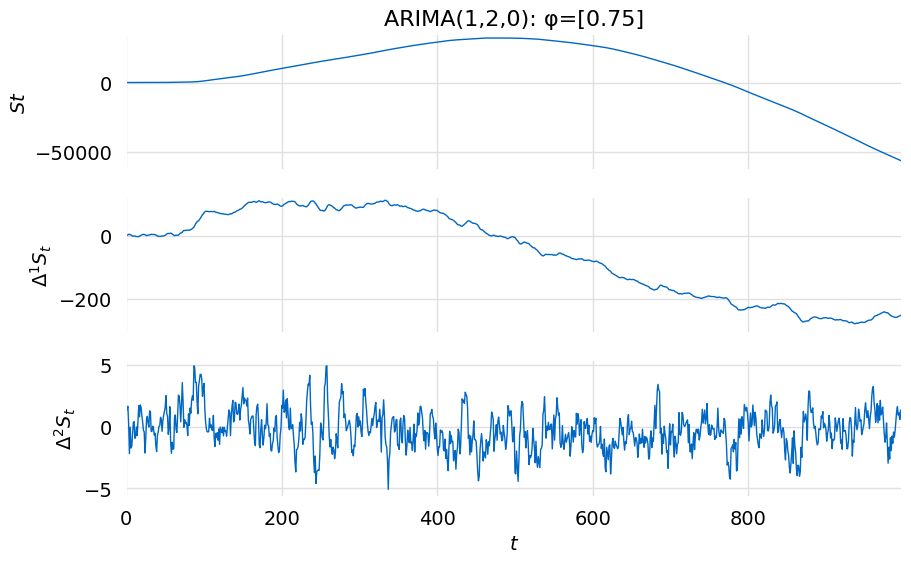

In [16]:
title = f"ARIMA(1,2,0): φ={φ}"
stack([arima_data, diff_1, diff_2], title=title, xlabel=r"$t$", ylabels=[r"$St$", r"$\Delta^1 S_t$", r"$\Delta^2 S_t$"])

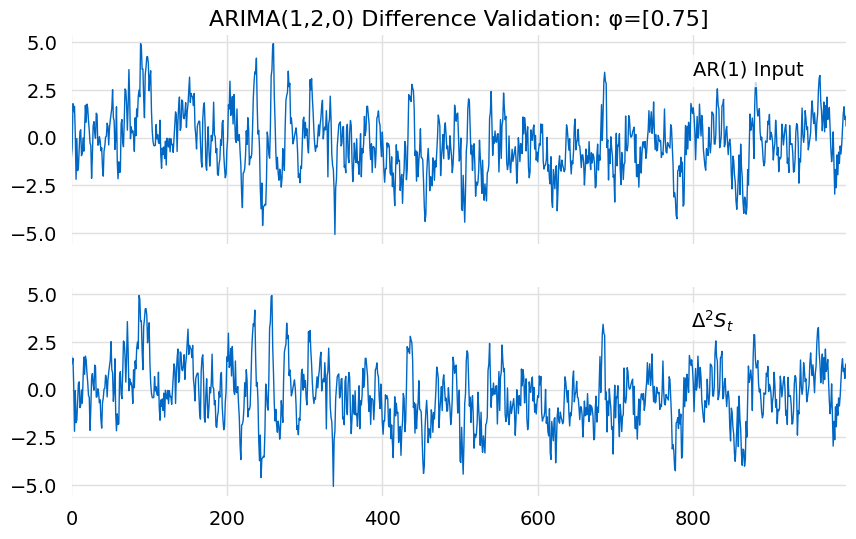

In [17]:
title = f"ARIMA(1,2,0) Difference Validation: φ={φ}"
stack([ar, diff_2], title=title, labels=[r"AR(1) Input", r"$\Delta^2 S_t$"])

In [18]:
result, report = adf.compute_adf_test(arima_data)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │  -3.39533     │
├────────────────┼───────────────┤
│ pvalue         │   0.000702265 │
├────────────────┼───────────────┤
│ Lags           │   2           │
├────────────────┼───────────────┤
│ Number Obs     │ 997           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [19]:
report.dict

{'Status': True,
 'HypothesisType': <HypothesisType.LOWER_TAIL: 'LOWER_TAIL'>,
 'HypothesisTestType': <HypothesisTestType.STATIONARITY: 'STATIONARITY'>,
 'Description': 'Stationarity Test',
 'TestData': [{'Status': False,
   'Statistic': {'Value': -3.395331686431932, 'Label': '$t$'},
   'PValue': {'Value': 0.0007022646148636951, 'Label': '$p-value$'},
   'Parameters': [],
   'Significance': {'Value': 0.01, 'Label': '1%'},
   'Lower Critical Value': {'Value': -2.5679861764430703, 'Label': '$t_L$'},
   'Upper Critical Value': None},
  {'Status': False,
   'Statistic': {'Value': -3.395331686431932, 'Label': '$t$'},
   'PValue': {'Value': 0.0007022646148636951, 'Label': '$p-value$'},
   'Parameters': [],
   'Significance': {'Value': 0.05, 'Label': '5%'},
   'Lower Critical Value': {'Value': -1.9412727620001924, 'Label': '$t_L$'},
   'Upper Critical Value': None},
  {'Status': False,
   'Statistic': {'Value': -3.395331686431932, 'Label': '$t$'},
   'PValue': {'Value': 0.0007022646148636951,

In [20]:
result, report = adf.compute_adf_test(diff_1)
result.summary()

╒════════════════╤════════════╕
│ Test Statistic │   1.05154  │
├────────────────┼────────────┤
│ pvalue         │   0.922855 │
├────────────────┼────────────┤
│ Lags           │   1        │
├────────────────┼────────────┤
│ Number Obs     │ 997        │
╘════════════════╧════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


In [21]:
report.dict

{'Status': False,
 'HypothesisType': <HypothesisType.LOWER_TAIL: 'LOWER_TAIL'>,
 'HypothesisTestType': <HypothesisTestType.STATIONARITY: 'STATIONARITY'>,
 'Description': 'Stationarity Test',
 'TestData': [{'Status': True,
   'Statistic': {'Value': 1.0515370962723403, 'Label': '$t$'},
   'PValue': {'Value': 0.9228553092608316, 'Label': '$p-value$'},
   'Parameters': [],
   'Significance': {'Value': 0.01, 'Label': '1%'},
   'Lower Critical Value': {'Value': -2.5679861764430703, 'Label': '$t_L$'},
   'Upper Critical Value': None},
  {'Status': True,
   'Statistic': {'Value': 1.0515370962723403, 'Label': '$t$'},
   'PValue': {'Value': 0.9228553092608316, 'Label': '$p-value$'},
   'Parameters': [],
   'Significance': {'Value': 0.05, 'Label': '5%'},
   'Lower Critical Value': {'Value': -1.9412727620001924, 'Label': '$t_L$'},
   'Upper Critical Value': None},
  {'Status': True,
   'Statistic': {'Value': 1.0515370962723403, 'Label': '$t$'},
   'PValue': {'Value': 0.9228553092608316, 'Label': '

In [22]:
result, report = adf.compute_adf_test(diff_2)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -11.2444      │
├────────────────┼───────────────┤
│ pvalue         │   2.25268e-20 │
├────────────────┼───────────────┤
│ Lags           │   0           │
├────────────────┼───────────────┤
│ Number Obs     │ 997           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [23]:
report.dict

{'Status': True,
 'HypothesisType': <HypothesisType.LOWER_TAIL: 'LOWER_TAIL'>,
 'HypothesisTestType': <HypothesisTestType.STATIONARITY: 'STATIONARITY'>,
 'Description': 'Stationarity Test',
 'TestData': [{'Status': False,
   'Statistic': {'Value': -11.244422492301377, 'Label': '$t$'},
   'PValue': {'Value': 2.2526768063639606e-20, 'Label': '$p-value$'},
   'Parameters': [],
   'Significance': {'Value': 0.01, 'Label': '1%'},
   'Lower Critical Value': {'Value': -2.5679861764430703, 'Label': '$t_L$'},
   'Upper Critical Value': None},
  {'Status': False,
   'Statistic': {'Value': -11.244422492301377, 'Label': '$t$'},
   'PValue': {'Value': 2.2526768063639606e-20, 'Label': '$p-value$'},
   'Parameters': [],
   'Significance': {'Value': 0.05, 'Label': '5%'},
   'Lower Critical Value': {'Value': -1.9412727620001924, 'Label': '$t_L$'},
   'Upper Critical Value': None},
  {'Status': False,
   'Statistic': {'Value': -11.244422492301377, 'Label': '$t$'},
   'PValue': {'Value': 2.252676806363960

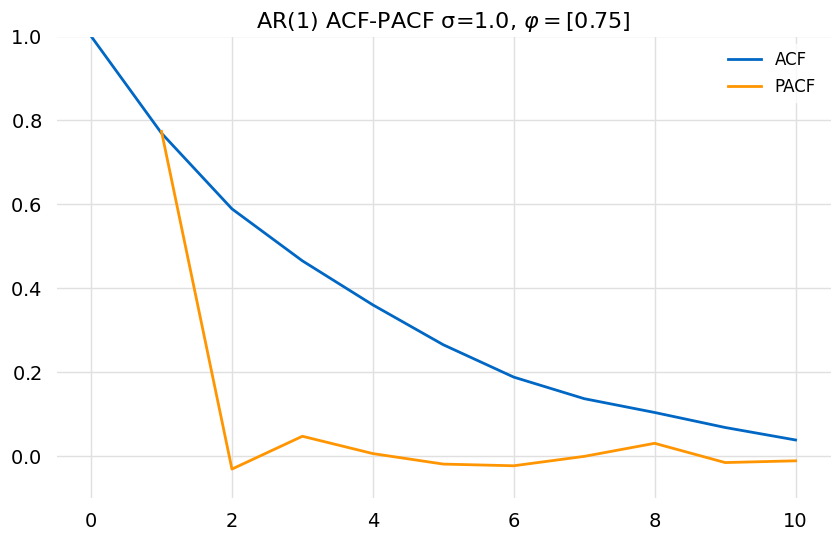

In [24]:
pacf_acf_plot(t, diff_2, nlags, σ, φ)

In [25]:
result, result_model = arima.compute_ar_estimate(diff_2, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  998
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1402.610
Date:                Sun, 23 Jul 2023   AIC                           2811.219
Time:                        11:17:05   BIC                           2825.936
Sample:                             0   HQIC                          2816.813
                                - 998                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2421      0.135     -1.794      0.073      -0.507       0.022
ar.L1          0.7697      0.019     39.543      0.000       0.732       0.808
sigma2         0.9724      0.044     21.914      0.000       0.885       1.059
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 0.87
Prob(Q):                              0.91   Prob(JB):                         0.65
Heteroskedasticity (H):               0.89   Skew:                            -0.06
Prob(H) (two-sided):                  0.31   Kurtosis:                         2.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## $\text{ARIMA}(2,2,0)$ Example

In [26]:
φ = [0.25, 0.4]
d = 2
_, ar = arima.create_ar_source(φ=φ, npts=nsample)
t, arima_data = arima.create_arima_from_arma_source(arma=ar, d=d, npts=nsample)
tdiff_1, diff_1 = stats.compute_ndiff(t, arima_data, ndiff=1)
tdiff_2, diff_2 = stats.compute_ndiff(t, arima_data, ndiff=2)

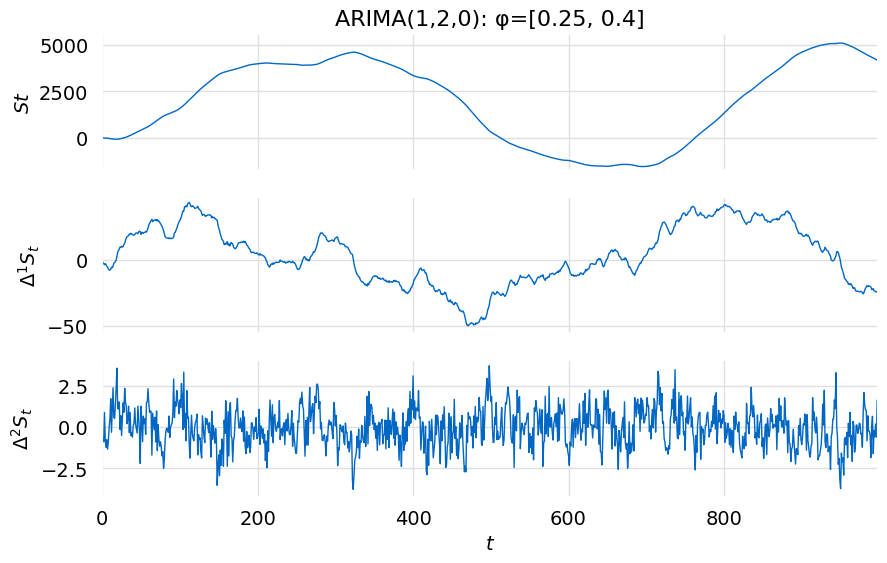

In [27]:
title = f"ARIMA(1,2,0): φ={φ}"
stack([arima_data, diff_1, diff_2], title=title, xlabel=r"$t$", ylabels=[r"$St$", r"$\Delta^1 S_t$", r"$\Delta^2 S_t$"])

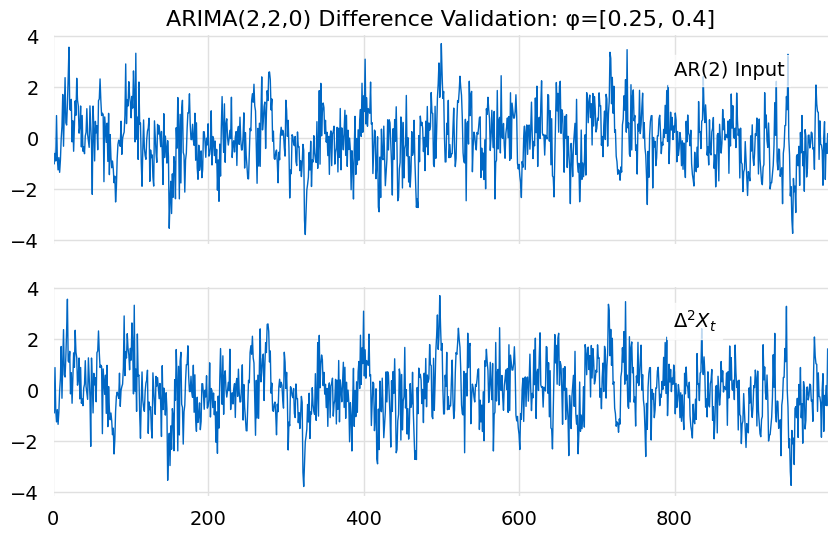

In [28]:
title = f"ARIMA(2,2,0) Difference Validation: φ={φ}"
stack([ar, diff_2], title=title, labels=[r"AR(2) Input", r"$\Delta^2 X_t$"])

In [29]:
result, report = adf.compute_adf_test(arima_data)
result.summary()

╒════════════════╤═════════════╕
│ Test Statistic │  -2.30686   │
├────────────────┼─────────────┤
│ pvalue         │   0.0202749 │
├────────────────┼─────────────┤
│ Lags           │   3         │
├────────────────┼─────────────┤
│ Number Obs     │ 996         │
╘════════════════╧═════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [30]:
report.dict

{'Status': True,
 'HypothesisType': <HypothesisType.LOWER_TAIL: 'LOWER_TAIL'>,
 'HypothesisTestType': <HypothesisTestType.STATIONARITY: 'STATIONARITY'>,
 'Description': 'Stationarity Test',
 'TestData': [{'Status': True,
   'Statistic': {'Value': -2.306864186583327, 'Label': '$t$'},
   'PValue': {'Value': 0.020274853630042788, 'Label': '$p-value$'},
   'Parameters': [],
   'Significance': {'Value': 0.01, 'Label': '1%'},
   'Lower Critical Value': {'Value': -2.567988435307495, 'Label': '$t_L$'},
   'Upper Critical Value': None},
  {'Status': False,
   'Statistic': {'Value': -2.306864186583327, 'Label': '$t$'},
   'PValue': {'Value': 0.020274853630042788, 'Label': '$p-value$'},
   'Parameters': [],
   'Significance': {'Value': 0.05, 'Label': '5%'},
   'Lower Critical Value': {'Value': -1.9412730391965518, 'Label': '$t_L$'},
   'Upper Critical Value': None},
  {'Status': False,
   'Statistic': {'Value': -2.306864186583327, 'Label': '$t$'},
   'PValue': {'Value': 0.020274853630042788, 'Lab

In [31]:
result, report = adf.compute_adf_test(diff_1)
result.summary()

╒════════════════╤═════════════╕
│ Test Statistic │  -1.71476   │
├────────────────┼─────────────┤
│ pvalue         │   0.0818735 │
├────────────────┼─────────────┤
│ Lags           │   2         │
├────────────────┼─────────────┤
│ Number Obs     │ 996         │
╘════════════════╧═════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [32]:
report.dict

{'Status': True,
 'HypothesisType': <HypothesisType.LOWER_TAIL: 'LOWER_TAIL'>,
 'HypothesisTestType': <HypothesisTestType.STATIONARITY: 'STATIONARITY'>,
 'Description': 'Stationarity Test',
 'TestData': [{'Status': True,
   'Statistic': {'Value': -1.7147609843740652, 'Label': '$t$'},
   'PValue': {'Value': 0.0818734568451634, 'Label': '$p-value$'},
   'Parameters': [],
   'Significance': {'Value': 0.01, 'Label': '1%'},
   'Lower Critical Value': {'Value': -2.567988435307495, 'Label': '$t_L$'},
   'Upper Critical Value': None},
  {'Status': True,
   'Statistic': {'Value': -1.7147609843740652, 'Label': '$t$'},
   'PValue': {'Value': 0.0818734568451634, 'Label': '$p-value$'},
   'Parameters': [],
   'Significance': {'Value': 0.05, 'Label': '5%'},
   'Lower Critical Value': {'Value': -1.9412730391965518, 'Label': '$t_L$'},
   'Upper Critical Value': None},
  {'Status': False,
   'Statistic': {'Value': -1.7147609843740652, 'Label': '$t$'},
   'PValue': {'Value': 0.0818734568451634, 'Label':

In [33]:
result, report = adf.compute_adf_test(diff_2)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -11.944       │
├────────────────┼───────────────┤
│ pvalue         │   9.17076e-22 │
├────────────────┼───────────────┤
│ Lags           │   1           │
├────────────────┼───────────────┤
│ Number Obs     │ 996           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [34]:
report.dict

{'Status': True,
 'HypothesisType': <HypothesisType.LOWER_TAIL: 'LOWER_TAIL'>,
 'HypothesisTestType': <HypothesisTestType.STATIONARITY: 'STATIONARITY'>,
 'Description': 'Stationarity Test',
 'TestData': [{'Status': False,
   'Statistic': {'Value': -11.943996746480396, 'Label': '$t$'},
   'PValue': {'Value': 9.170763711007296e-22, 'Label': '$p-value$'},
   'Parameters': [],
   'Significance': {'Value': 0.01, 'Label': '1%'},
   'Lower Critical Value': {'Value': -2.567988435307495, 'Label': '$t_L$'},
   'Upper Critical Value': None},
  {'Status': False,
   'Statistic': {'Value': -11.943996746480396, 'Label': '$t$'},
   'PValue': {'Value': 9.170763711007296e-22, 'Label': '$p-value$'},
   'Parameters': [],
   'Significance': {'Value': 0.05, 'Label': '5%'},
   'Lower Critical Value': {'Value': -1.9412730391965518, 'Label': '$t_L$'},
   'Upper Critical Value': None},
  {'Status': False,
   'Statistic': {'Value': -11.943996746480396, 'Label': '$t$'},
   'PValue': {'Value': 9.170763711007296e-2

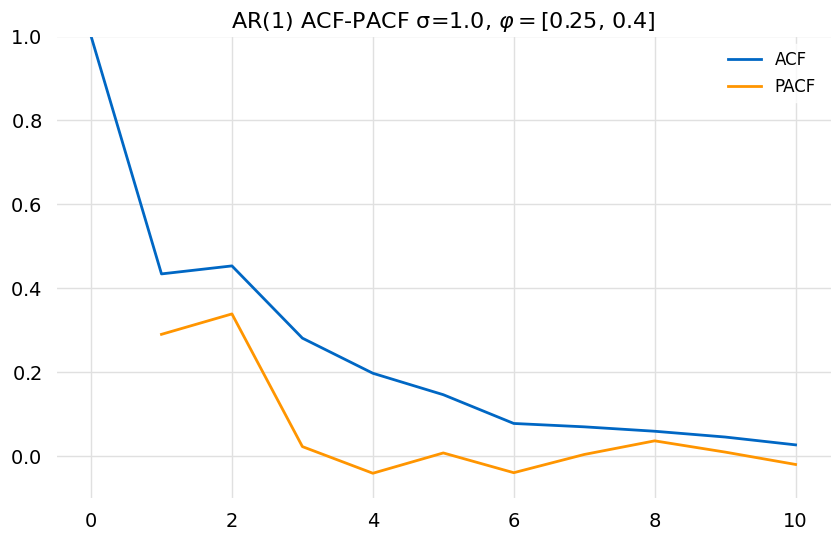

In [35]:
pacf_acf_plot(t, diff_2, nlags, σ, φ)

In [36]:
result, result_model = arima.compute_ar_estimate(diff_2, order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  998
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1415.903
Date:                Sun, 23 Jul 2023   AIC                           2839.806
Time:                        11:17:06   BIC                           2859.429
Sample:                             0   HQIC                          2847.265
                                - 998                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0218      0.083     -0.262      0.793      -0.185       0.141
ar.L1          0.2924      0.030      9.908      0.000       0.235       0.350
ar.L2          0.3262      0.031     10.447      0.000       0.265       0.387
sigma2         0.9992      0.046     21.705      0.000       0.909       1.089
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 0.29
Prob(Q):                              0.92   Prob(JB):                         0.87
Heteroskedasticity (H):               0.98   Skew:                            -0.01
Prob(H) (two-sided):                  0.84   Kurtosis:                         2.92
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""